# 4. β ladder — is square intrinsically ρ-limited, or only at β=1?

Notebook 01 measured `R = 1.0425` for the square model and notebook 02 explained it: the mates'
noise is almost perfectly correlated, `ρ ≈ 0.94`, and

$$r \;=\; \frac{m}{1+(m-1)\rho}$$

collapses to ~1 as `ρ → 1`. The natural reading was *"the single-band square model has symmetric
noise"*. But β=1 is **also** the regime where noise is dominated by symmetric scalar channels — so
that reading confounds **the model** with **the temperature**. This notebook separates them by
sweeping β with everything else held fixed.

**The prediction.** As β rises the correlation length grows, the noise acquires symmetry-*breaking*
structure, `ρ` falls and `R` rises. If so, square is not intrinsically ρ-limited and the β=1 number
is a property of the regime, not of the model.

**The competing effect, and why this ladder does not suffer from it.** `G = ⟨sign·M⟩/⟨sign⟩`, and a
fluctuation of that scalar denominator gives `δG(k) = −G(k)·δs/s` — a weight `−G(k)` that is itself
symmetric. So **sign-problem noise is a fully symmetric channel with mate-correlation exactly 1**,
pushing `ρ` *up* and `R` toward 1. Any model with a sign problem mixes the two effects and a bare
`R(β)` curve cannot say which is acting.

Square avoids this **by construction**: nearest-neighbour hopping on a bipartite lattice at half
filling (μ=0) is provably sign-free in CT-AUX at *any* β. The runs confirm it — `⟨sign⟩` is exactly 1
on every rank at every β — so this ladder isolates the correlation-length effect with the sign
channel switched off. That is checked below, not assumed.

**Design.** 4×4 cluster, D4, 64 ranks, **2048 measurements per rank**, **32 independent base seeds
per β**, β ∈ {1, 2, 4, 8}. The depth clears every rung's floor by 8× (measured separately: the floor
is 64 at β=1,2 and 256 at β=4,8 — it *rises* with β, so it was re-established at each rung rather
than inherited). Each β gets a disjoint base-seed range, so no two rungs share walker streams.

In [1]:
import sys, json
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
import beta_ladder as bl

plt.rcParams['figure.dpi'] = 110
S = json.load(open('../runs/beta_ladder_square.json'))
rows = S['report']['rungs']
print(f"{len(S['runs'])} runs | betas {[r['beta'] for r in rows]} | "
      f"seeds/rung {[r['n_seeds'] for r in rows]} | depth {sorted({r['m'] for r in rows})} per rank")
print('seed-spacing violations:', S['report']['seed_spacing_violations'] or 'none')

128 runs | betas [1.0, 2.0, 4.0, 8.0] | seeds/rung [32, 32, 32, 32] | depth [2048] per rank
seed-spacing violations: none


## The result

`R` on the full support, averaged over base seeds, with the standard error across seeds — the same
estimator and the same conventions as the milestone-6 headline numbers.

In [2]:
print(bl.rung_table(rows))

 beta seeds  m/rank       R (mean +/- sem)           95% t-CI      rho (mates)       <s>   outl
    1    32    2048         1.0414 +/- 0.0015 [1.0383,1.0445]    0.9389 +/- 0.0021   1.00000   1.02
    2    32    2048         1.1406 +/- 0.0029 [1.1347,1.1465]    0.8246 +/- 0.0030   1.00000   1.03
    4    32    2048         1.2122 +/- 0.0065 [1.1990,1.2254]    0.7240 +/- 0.0053   1.00000   1.07
    8    32    2048         1.3429 +/- 0.0088 [1.3249,1.3609]    0.5575 +/- 0.0062   1.00000   1.34


## ρ falls, R rises

Left: the mate-correlation `ρ` against β. Right: `R` against β. The band is the 95% t-interval on
the mean across seeds.

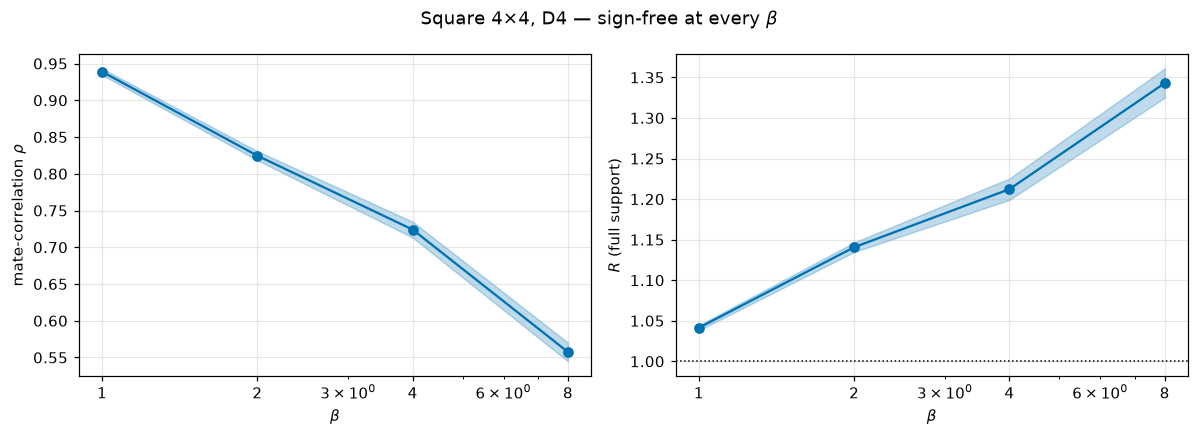

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
b = np.array([r['beta'] for r in rows], float)
for ax, key, lab in ((axes[0], 'rho', r'mate-correlation $\rho$'),
                     (axes[1], 'R_full', r'$R$ (full support)')):
    m  = np.array([r[key]['mean'] for r in rows])
    lo = np.array([r[key]['lo'] for r in rows])
    hi = np.array([r[key]['hi'] for r in rows])
    ax.fill_between(b, lo, hi, alpha=.25, color='#0072B2')
    ax.plot(b, m, 'o-', color='#0072B2')
    ax.set(xscale='log', xticks=b, xlabel=r'$\beta$', ylabel=lab)
    ax.set_xticklabels([f'{x:g}' for x in b])
    ax.grid(alpha=.3)
axes[1].axhline(1.0, ls=':', c='k', lw=1)
fig.suptitle(r'Square 4$\times$4, D4 — sign-free at every $\beta$')
plt.tight_layout()

## Is the trend resolved?

Four rungs is too few for a regression to carry weight, so two things four points *can* support are
reported: the endpoint change with an interval built by resampling **seeds within each rung** (the
level of independent replication the design actually has), and whether every rung-to-rung step shares
one sign. Monotonicity alone is weak — three steps agreeing has probability 0.25 under an
exchangeable null — so it is only meaningful beside an endpoint interval that excludes zero.

In [4]:
print(bl.trend_table(S['report']['trends']))

quantity           beta range       change                 95% CI  monotone   verdict
R_full                   1->8      +0.3015 [+0.2837,+0.3188]      True  resolved
rho                      1->8      -0.3814 [-0.3945,-0.3688]      True  resolved


## The precondition: the sign channel must stay off

The whole interpretation rests on this. If `⟨sign⟩` drifted below 1 anywhere on the ladder, a
perfectly-symmetric noise channel would start feeding `ρ` and could be mistaken for the effect
saturating.

In [5]:
print(bl.sign_table(rows))

 beta    min <s>    max <s>  sign-free  worst outlier
    1   1.000000   1.000000       True          1.016
    2   1.000000   1.000000       True          1.029
    4   1.000000   1.000000       True          1.069
    8   1.000000   1.000000       True          1.341


## Control: `r` must stay flat in ω

The input template fixes `sp-fermionic-frequencies` at 128 regardless of β, and Matsubara
frequencies are spaced `π/β` — so the window in **absolute** energy units shrinks as β grows, and
each rung sums `R` over a different slice of frequency space. That would confound the ladder *if* `r`
depended on ω.

It should not: the point group acts on band and momentum indices and does not touch Matsubara
frequency. Measuring the slope at every β turns that from an assumption inherited from β=1 into a
per-rung check.

In [6]:
print(bl.omega_table(rows))

 beta  runs         slope per step      drift across window   verdict
    1    32      -1.40e-18 +/- 3.0e-18           0.0000% +/- 0.0000%      flat
    2    32      -4.72e-18 +/- 2.4e-18           0.0000% +/- 0.0000%      flat
    4    32      -3.62e-18 +/- 1.5e-18           0.0000% +/- 0.0000%      flat
    8    32      -3.46e-18 +/- 9.2e-19           0.0000% +/- 0.0000%      flat


## Mechanism: per-orbit ρ and the `m/[1+(m−1)ρ]` law

The aggregate `R` is a variance-weighted mixture over orbits. Resolving it per orbit shows the law
holding rung by rung — and measured-vs-predicted `r` doubles as the contamination detector, since a
run whose variance is set by one outlying rank breaks the identity.

In [7]:
print(bl.orbit_table(rows))

 beta   m    rho (mean +/- sem)         r measured        r predicted  max|gap|
    1   4        0.9512 +/- 0.0017     1.0381 +/- 0.0014     1.0380 +/- 0.0014  3.45e-04
    1   4        0.9671 +/- 0.0011     1.0254 +/- 0.0009     1.0253 +/- 0.0009  5.37e-04
    1   4        0.9512 +/- 0.0017     1.0381 +/- 0.0014     1.0380 +/- 0.0014  3.45e-04
    1   2        0.8331 +/- 0.0067     1.0915 +/- 0.0041     1.0915 +/- 0.0041  3.11e-15
    2   4        0.8500 +/- 0.0028     1.1271 +/- 0.0027     1.1270 +/- 0.0027  1.25e-03
    2   4        0.8733 +/- 0.0030     1.1055 +/- 0.0028     1.1052 +/- 0.0027  1.54e-03
    2   4        0.8500 +/- 0.0028     1.1271 +/- 0.0027     1.1270 +/- 0.0027  1.25e-03
    2   2        0.6255 +/- 0.0094     1.2317 +/- 0.0072     1.2317 +/- 0.0072  4.44e-15
    4   4        0.7200 +/- 0.0045     1.2667 +/- 0.0054     1.2666 +/- 0.0054  5.60e-04
    4   4        0.7878 +/- 0.0058     1.1907 +/- 0.0063     1.1903 +/- 0.0063  3.20e-03
    4   4        0.7200 +/- 0.

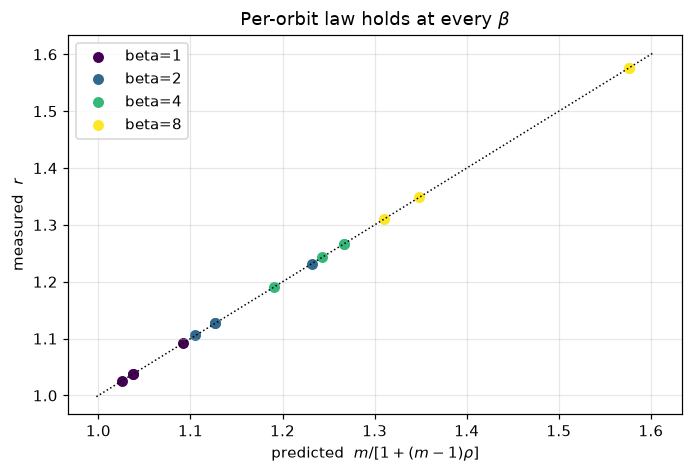

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for r in rows:
    for o in r['orbits']:
        ax.scatter(o['r_pred']['mean'], o['r']['mean'], s=38,
                   label=f"beta={r['beta']:g}" if o is r['orbits'][0] else None,
                   color=plt.cm.viridis(np.log2(r['beta'])/3))
lim = ax.get_xlim()
ax.plot(lim, lim, 'k:', lw=1)
ax.set(xlabel=r'predicted  $m/[1+(m-1)\rho]$', ylabel=r'measured  $r$',
       title=r'Per-orbit law holds at every $\beta$')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()

## What this establishes, and what it does not

**Establishes.** `ρ` falls and `R` rises monotonically across β ∈ {1,2,4,8} on the square model, with
the endpoint change resolved against across-seed scatter. **Square is not intrinsically ρ-limited** —
its β=1 value of `R ≈ 1.04` is a property of that temperature regime, not of the single-band square
model. The `m/[1+(m−1)ρ]` law holds rung by rung, so the gain is fully accounted for by the mechanism
notebook 02 identified.

**Does not establish.** This ladder says nothing about the *competing* sign channel, because square
has no sign problem to exercise it — that is exactly why it is the clean instrument for the
correlation-length axis, and exactly why it cannot settle where the two effects cross over. That
needs a β ladder on a model that *has* a sign problem, where `⟨sign⟩` and `ρ` can be tracked
together.

**Scope, unchanged.** This is `Var(G)` for a single-iteration estimator on a 4×4 cluster in plain
DCA under CT-AUX. Observable-level variance stays out of scope.